<div style="text-align:center;">

# Comparación de Modelos — Clasificación de Rotación
### *Base vs Ajustado — Selección del candidato óptimo*

---
**Universidad de Antioquia — Instituto de Matemáticas**  
*Analítica de Datos — Laboratorio 5*

</div>

---

## Propósito de este notebook

Integra los resultados de los **cuatro modelos** entrenados en notebooks independientes, ahora con dos versiones cada uno:

| Notebook | Versión Base | Versión Ajustada (RandomizedSearchCV) |
|:---------|:------------:|:-------------------------------------:|
| `1.Regresion_Logistica.ipynb` | ✓ | ✓ |
| `2.Arbol_Clasificacion.ipynb` | ✓ | ✓ |
| `3.Random_Forest.ipynb` | ✓ | ✓ |
| `4.XGBoost.ipynb` | ✓ | ✓ |

Y produce:

1. Tabla comparativa **base vs ajustado** con las cinco métricas en CV.
2. Visualizaciones del salto en desempeño tras el tuning.
3. Comparación de los **umbrales óptimos** ($\tau$) hallados por modelo.
4. Discusión técnica y **recomendación del modelo final** para el problema de Attrition.


---
## 1. Carga de los resultados

In [1]:
import warnings
warnings.filterwarnings("ignore")

import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

plt.rcParams.update({
    "figure.dpi"        : 120,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "axes.titleweight"  : "bold",
    "axes.titlesize"    : 12,
    "axes.labelsize"    : 10,
    "font.size"         : 10,
    "legend.frameon"    : False,
})

# Colores por modelo (consistentes con notebooks individuales)
COLORES = {
    "Regresión Logística": "#1f77b4",
    "Árbol de Decisión"  : "#ff7f0e",
    "Random Forest"      : "#2ca02c",
    "XGBoost"            : "#d62728",
}
COLOR_BASE  = "#bdc3c7"
COLOR_TUNED = "#2c3e50"

RUTA = Path("cv_results")
archivos = sorted(RUTA.glob("*.json"))

datos = {}
for archivo in archivos:
    with open(archivo, "r", encoding="utf-8") as f:
        d = json.load(f)
    datos[d["modelo"]] = d

print("Modelos cargados:")
for nombre in datos:
    print(f"  · {nombre}")

Modelos cargados:
  · Árbol de Decisión
  · Random Forest
  · Regresión Logística
  · XGBoost


---
## 2. Tabla comparativa — modelos base

In [2]:
ORDEN_MODELOS = ["Regresión Logística", "Árbol de Decisión", "Random Forest", "XGBoost"]
ORDEN_METRICAS = ["accuracy", "precision", "recall", "f1", "roc_auc"]
NOMBRES_METRICAS = {"accuracy": "Accuracy", "precision": "Precision",
                    "recall": "Recall", "f1": "F1-Score", "roc_auc": "AUC"}

def tabla_modelos(datos, key_metricas):
    filas = []
    for modelo in ORDEN_MODELOS:
        fila = {"Modelo": modelo}
        for m in ORDEN_METRICAS:
            mu = datos[modelo][key_metricas][m]["mu"]
            sg = datos[modelo][key_metricas][m]["sigma"]
            fila[f"{NOMBRES_METRICAS[m]} (Media ± Desv.)"] = f"{mu:.4f} ± {sg:.4f}"
        filas.append(fila)
    return pd.DataFrame(filas).set_index("Modelo")

tabla_base = tabla_modelos(datos, "metricas_base")
tabla_base

,Accuracy (Media ± Desv.),Precision (Media ± Desv.),Recall (Media ± Desv.),F1-Score (Media ± Desv.),AUC (Media ± Desv.)
Modelo,,,,,
Regresión Logística,0.7668 ± 0.0178,0.3854 ± 0.0317,0.7529 ± 0.0846,0.5092 ± 0.0442,0.8230 ± 0.0547
Árbol de Decisión,0.7998 ± 0.0209,0.3736 ± 0.0686,0.3556 ± 0.0656,0.3642 ± 0.0663,0.6204 ± 0.0384
Random Forest,0.8591 ± 0.0055,0.8362 ± 0.1404,0.1688 ± 0.0415,0.2761 ± 0.0528,0.8026 ± 0.0375
XGBoost,0.8756 ± 0.0129,0.6683 ± 0.0603,0.4583 ± 0.0584,0.5419 ± 0.0539,0.8124 ± 0.0383


---
## 3. Tabla comparativa — modelos ajustados (post-tuning)

In [3]:
tabla_tuned = tabla_modelos(datos, "metricas_tuned")
tabla_tuned

,Accuracy (Media ± Desv.),Precision (Media ± Desv.),Recall (Media ± Desv.),F1-Score (Media ± Desv.),AUC (Media ± Desv.)
Modelo,,,,,
Regresión Logística,0.8494 ± 0.0185,0.5258 ± 0.0487,0.6389 ± 0.1122,0.5743 ± 0.0702,0.8344 ± 0.0582
Árbol de Decisión,0.7697 ± 0.0278,0.3700 ± 0.0453,0.5727 ± 0.0473,0.4464 ± 0.0289,0.7022 ± 0.0438
Random Forest,0.8542 ± 0.0206,0.5568 ± 0.0778,0.5000 ± 0.0559,0.5259 ± 0.0614,0.7956 ± 0.0373
XGBoost,0.8707 ± 0.0154,0.6096 ± 0.0544,0.5667 ± 0.0647,0.5850 ± 0.0490,0.8258 ± 0.0264


In [4]:
# Mejor modelo por métrica (tras tuning)
print("Mejor modelo por métrica (sobre la versión ajustada):")
print("─" * 60)
for m in ORDEN_METRICAS:
    valores = {mod: datos[mod]["metricas_tuned"][m]["mu"] for mod in ORDEN_MODELOS}
    ganador, val = max(valores.items(), key=lambda x: x[1])
    print(f"  {NOMBRES_METRICAS[m]:<12s} → {ganador:<22s}  Media = {val:.4f}")
print("─" * 60)

Mejor modelo por métrica (sobre la versión ajustada):
────────────────────────────────────────────────────────────
  Accuracy     → XGBoost                 Media = 0.8707
  Precision    → XGBoost                 Media = 0.6096
  Recall       → Regresión Logística     Media = 0.6389
  F1-Score     → XGBoost                 Media = 0.5850
  AUC          → Regresión Logística     Media = 0.8344
────────────────────────────────────────────────────────────


---
## 4. Delta de mejora — Tuned − Base

In [5]:
filas = []
for modelo in ORDEN_MODELOS:
    fila = {"Modelo": modelo}
    for m in ORDEN_METRICAS:
        b = datos[modelo]["metricas_base"][m]["mu"]
        t = datos[modelo]["metricas_tuned"][m]["mu"]
        fila[f"Δ {NOMBRES_METRICAS[m]}"] = round(t - b, 4)
    filas.append(fila)
tabla_delta = pd.DataFrame(filas).set_index("Modelo")
tabla_delta

,Δ Accuracy,Δ Precision,Δ Recall,Δ F1-Score,Δ AUC
Modelo,,,,,
Regresión Logística,0.0826,0.1404,-0.1141,0.0651,0.0114
Árbol de Decisión,-0.0301,-0.0037,0.2171,0.0822,0.0818
Random Forest,-0.0049,-0.2794,0.3312,0.2498,-0.0070
XGBoost,-0.0049,-0.0587,0.1084,0.0431,0.0134


---
## 5. Visualización 1 — Base vs Ajustado por métrica

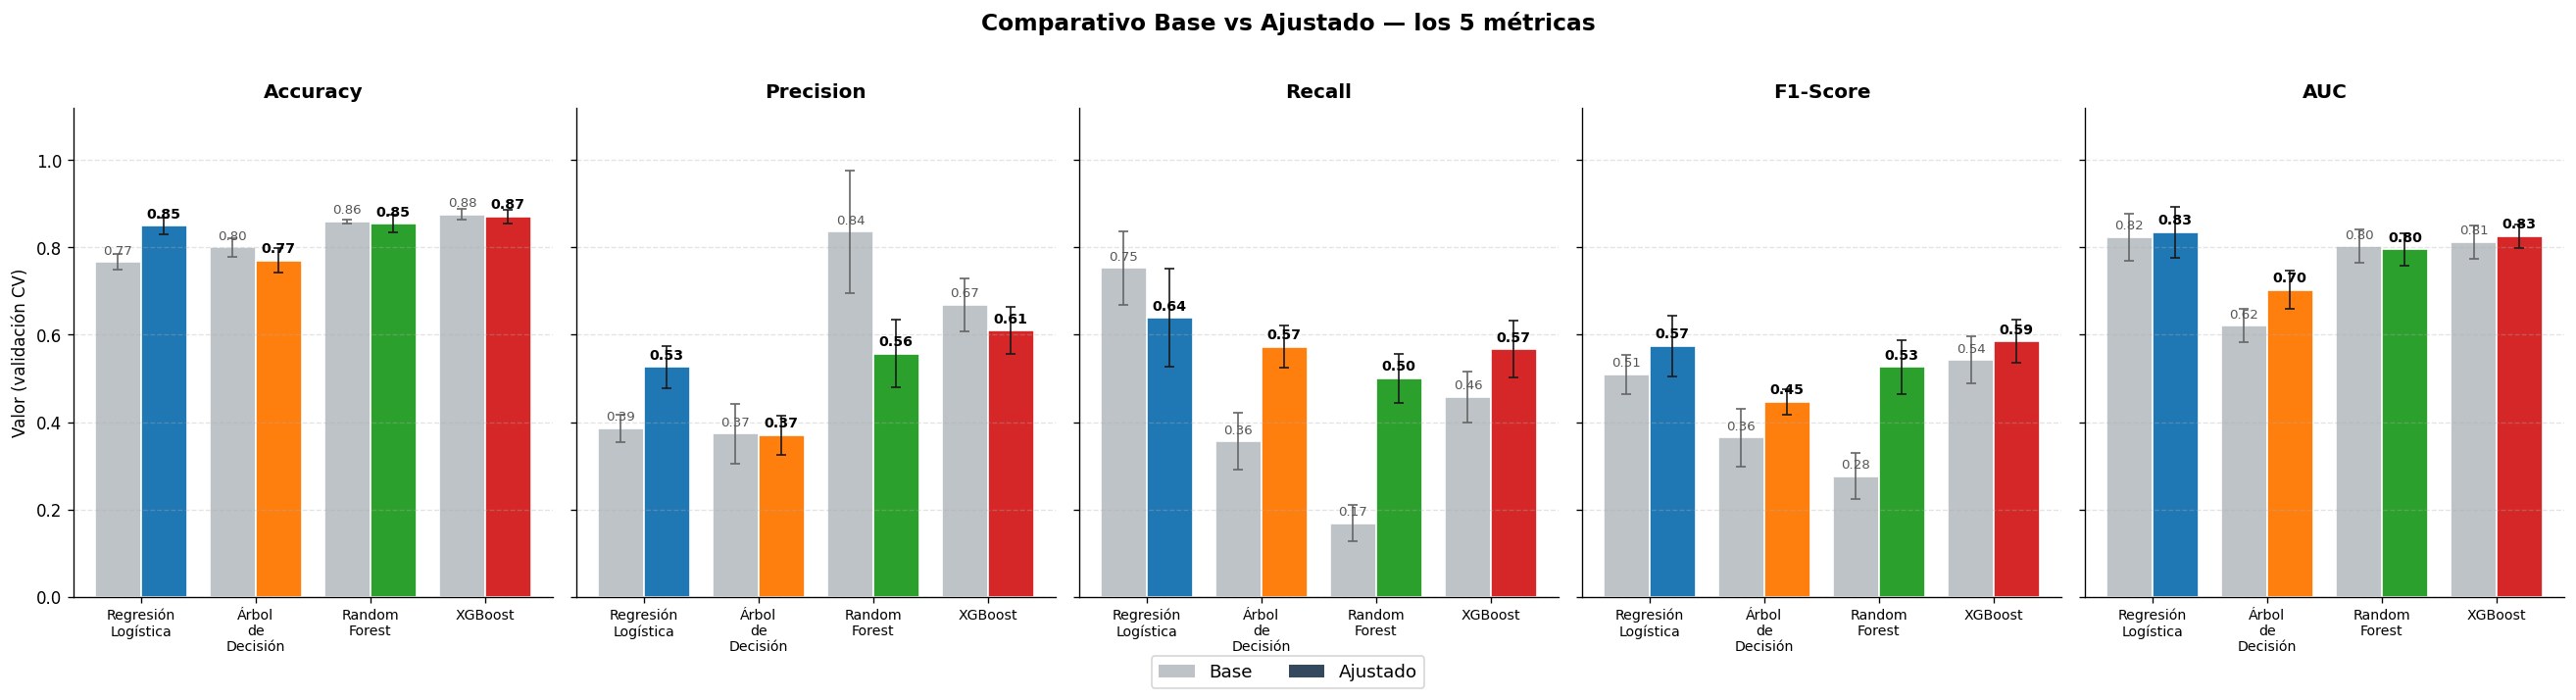

In [6]:
fig, axes = plt.subplots(1, 5, figsize=(22, 5.5), sharey=True)

for ax, m in zip(axes, ORDEN_METRICAS):
    x = np.arange(len(ORDEN_MODELOS))
    medias_b = [datos[mod]["metricas_base"][m]["mu"]  for mod in ORDEN_MODELOS]
    medias_t = [datos[mod]["metricas_tuned"][m]["mu"] for mod in ORDEN_MODELOS]
    stds_b   = [datos[mod]["metricas_base"][m]["sigma"]  for mod in ORDEN_MODELOS]
    stds_t   = [datos[mod]["metricas_tuned"][m]["sigma"] for mod in ORDEN_MODELOS]

    bb = ax.bar(x - 0.2, medias_b, 0.4, yerr=stds_b, capsize=3,
                color=COLOR_BASE, edgecolor="white",
                error_kw=dict(elinewidth=1, ecolor="#666"))
    bt = ax.bar(x + 0.2, medias_t, 0.4, yerr=stds_t, capsize=3,
                color=[COLORES[mod] for mod in ORDEN_MODELOS],
                edgecolor="white",
                error_kw=dict(elinewidth=1, ecolor="#1a1a1a"))

    for b, v in zip(bb, medias_b):
        ax.text(b.get_x()+b.get_width()/2, v + 0.018,
                f"{v:.2f}", ha="center", fontsize=8, color="#555")
    for b, v in zip(bt, medias_t):
        ax.text(b.get_x()+b.get_width()/2, v + 0.018,
                f"{v:.2f}", ha="center", fontsize=8.5, fontweight="bold")

    ax.set_xticks(x)
    ax.set_xticklabels([mod.replace(" ", "\n") for mod in ORDEN_MODELOS],
                       fontsize=8.5)
    ax.set_title(NOMBRES_METRICAS[m], fontsize=12)
    ax.set_ylim(0, 1.12)
    ax.grid(axis="y", ls="--", alpha=0.35)
    if ax is axes[0]:
        ax.set_ylabel("Valor (validación CV)")

# Leyenda global
handles = [Patch(facecolor=COLOR_BASE, label="Base"),
           Patch(facecolor="#34495e",  label="Ajustado")]
fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, -0.04),
           ncol=2, frameon=True, fancybox=True, fontsize=11)

fig.suptitle("Comparativo Base vs Ajustado — los 5 métricas", fontsize=14,
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
## 6. Visualización 2 — Heatmap del impacto del tuning

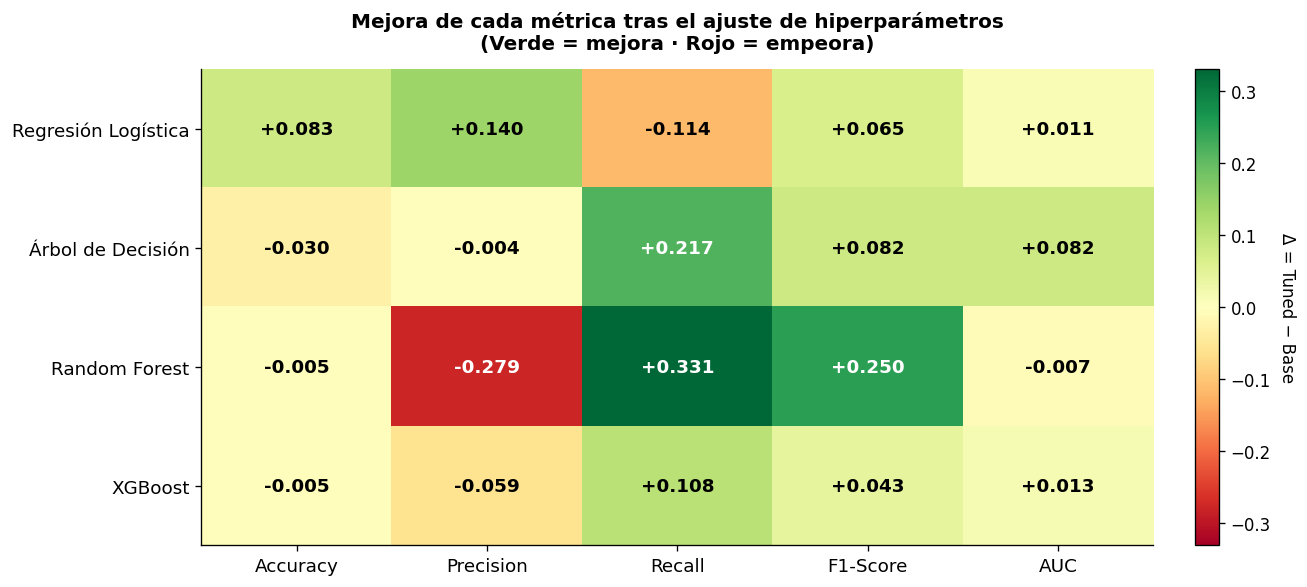

In [7]:
matriz_delta = np.array([
    [datos[mod]["metricas_tuned"][m]["mu"] - datos[mod]["metricas_base"][m]["mu"]
     for m in ORDEN_METRICAS]
    for mod in ORDEN_MODELOS
])

fig, ax = plt.subplots(figsize=(11, 5))
vmax = max(abs(matriz_delta.min()), abs(matriz_delta.max()))
im = ax.imshow(matriz_delta, cmap="RdYlGn", aspect="auto", vmin=-vmax, vmax=vmax)

ax.set_xticks(np.arange(len(ORDEN_METRICAS)))
ax.set_xticklabels([NOMBRES_METRICAS[m] for m in ORDEN_METRICAS], fontsize=11)
ax.set_yticks(np.arange(len(ORDEN_MODELOS)))
ax.set_yticklabels(ORDEN_MODELOS, fontsize=11)

for i in range(len(ORDEN_MODELOS)):
    for j in range(len(ORDEN_METRICAS)):
        v = matriz_delta[i, j]
        signo = "+" if v >= 0 else ""
        color = "white" if abs(v) > vmax * 0.55 else "black"
        ax.text(j, i, f"{signo}{v:.3f}", ha="center", va="center",
                color=color, fontsize=11, fontweight="bold")

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Δ = Tuned − Base", rotation=270, labelpad=15)

ax.set_title("Mejora de cada métrica tras el ajuste de hiperparámetros\n(Verde = mejora · Rojo = empeora)",
             fontsize=12, pad=12)
plt.tight_layout()
plt.show()

---
## 7. Visualización 3 — Perfil radial de los modelos ajustados

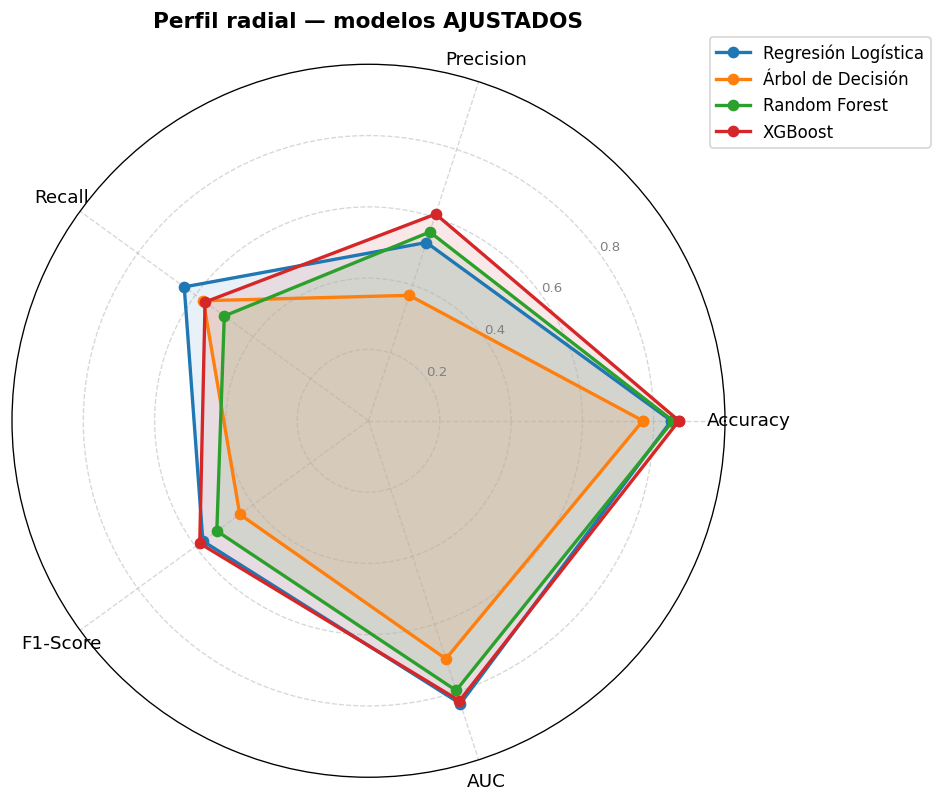

In [8]:
angulos = np.linspace(0, 2*np.pi, len(ORDEN_METRICAS), endpoint=False).tolist()
angulos += angulos[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for modelo in ORDEN_MODELOS:
    vals = [datos[modelo]["metricas_tuned"][m]["mu"] for m in ORDEN_METRICAS]
    vals += vals[:1]
    ax.plot(angulos, vals, "-o", color=COLORES[modelo], lw=2,
            label=modelo, markersize=6)
    ax.fill(angulos, vals, color=COLORES[modelo], alpha=0.10)

ax.set_xticks(angulos[:-1])
ax.set_xticklabels([NOMBRES_METRICAS[m] for m in ORDEN_METRICAS], fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8])
ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8"], fontsize=8, color="gray")
ax.set_rlabel_position(180/len(ORDEN_METRICAS))

ax.set_title("Perfil radial — modelos AJUSTADOS", fontsize=13, pad=22)
ax.legend(loc="upper right", bbox_to_anchor=(1.30, 1.05),
          fontsize=10, frameon=True, fancybox=True)
ax.grid(ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

---
## 8. Hiperparámetros óptimos por modelo

In [9]:
for modelo in ORDEN_MODELOS:
    print(f"── {modelo}")
    for k, v in datos[modelo]["best_params"].items():
        print(f"     {k.replace('clf__',''):<22s} = {v}")
    print()

── Regresión Logística
     C                      = 0.1906609163818847
     class_weight           = {0: 1, 1: 3}
     penalty                = l1
     solver                 = saga

── Árbol de Decisión
     ccp_alpha              = 0.01333905071376425
     class_weight           = {0: 1, 1: 3}
     criterion              = entropy
     max_depth              = 24
     max_features           = None
     min_samples_leaf       = 5
     min_samples_split      = 33

── Random Forest
     bootstrap              = False
     class_weight           = balanced
     max_depth              = 16
     max_features           = log2
     min_samples_leaf       = 8
     min_samples_split      = 12
     n_estimators           = 180

── XGBoost
     colsample_bytree       = 0.8270801311279966
     gamma                  = 0.01565664622777929
     learning_rate          = 0.17545136166066808
     max_depth              = 6
     min_child_weight       = 2
     n_estimators           = 301
     reg_alp

---
## 9. Comparación de umbrales óptimos

Para cada modelo ajustado se encontraron dos umbrales:

- **$\tau_{F1}$** — maximiza el F1 (balance Precision-Recall).
- **$\tau_{\text{recall}}$** — maximiza Recall sujeto a Precision $\geq 0.40$ (criterio del negocio).


In [10]:
filas = []
for modelo in ORDEN_MODELOS:
    th = datos[modelo]["thresholds"]
    filas.append({
        "Modelo": modelo,
        "τ default": 0.50,
        "τ_F1 (máx F1)": round(th["tau_f1"], 3),
        "τ_Recall (Recall máx | P ≥ 0.40)": round(th["tau_recall"], 3),
    })
pd.DataFrame(filas).set_index("Modelo")

,τ default,τ_F1 (máx F1),τ_Recall (Recall máx | P ≥ 0.40)
Modelo,,,
Regresión Logística,0.5,0.545,0.379
Árbol de Decisión,0.5,0.545,0.639
Random Forest,0.5,0.495,0.402
XGBoost,0.5,0.472,0.209


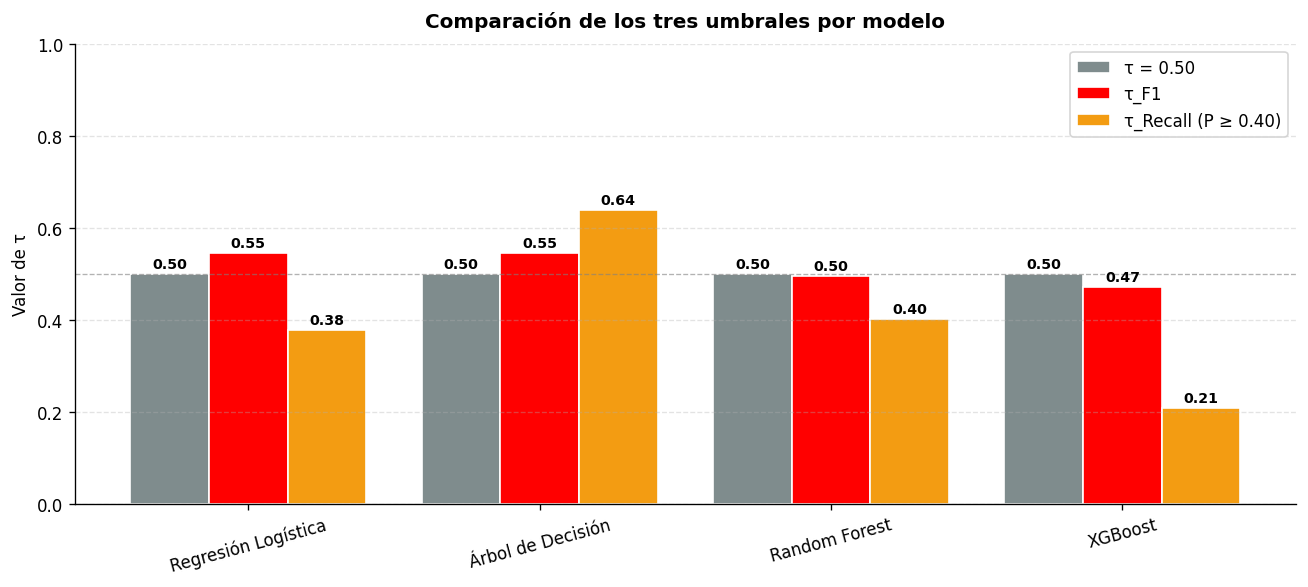

In [11]:
fig, ax = plt.subplots(figsize=(11, 5))

x = np.arange(len(ORDEN_MODELOS))
ancho = 0.27

t_def = [0.50] * len(ORDEN_MODELOS)
t_f1  = [datos[mod]["thresholds"]["tau_f1"]     for mod in ORDEN_MODELOS]
t_rec = [datos[mod]["thresholds"]["tau_recall"] for mod in ORDEN_MODELOS]

ax.bar(x - ancho, t_def, ancho, color="#7f8c8d", edgecolor="white", label="τ = 0.50")
ax.bar(x,         t_f1,  ancho, color="red",      edgecolor="white", label="τ_F1")
ax.bar(x + ancho, t_rec, ancho, color="#f39c12",  edgecolor="white", label="τ_Recall (P ≥ 0.40)")

for i, vs in enumerate(zip(t_def, t_f1, t_rec)):
    for offset, v in zip([-ancho, 0, ancho], vs):
        ax.text(i + offset, v + 0.013, f"{v:.2f}",
                ha="center", fontsize=8.5, fontweight="bold")

ax.axhline(0.5, color="gray", ls="--", lw=0.8, alpha=0.6)
ax.set_xticks(x); ax.set_xticklabels(ORDEN_MODELOS, rotation=15)
ax.set_ylabel("Valor de τ")
ax.set_ylim(0, 1)
ax.set_title("Comparación de los tres umbrales por modelo", pad=10)
ax.legend(loc="upper right", frameon=True, fancybox=True)
ax.grid(axis="y", ls="--", alpha=0.35)
plt.tight_layout()
plt.show()

---
## 10. Discusión técnica — selección del modelo final

### 10.1 Lectura individual de cada modelo (post-tuning)

| Modelo | F1 (val) | Recall (val) | AUC (val) | Lectura |
|:-------|:--------:|:------------:|:---------:|:--------|
| **Regresión Logística** | 0.574 | 0.639 | **0.834** | Mejor AUC y excelente Recall. Estable, interpretable. El tuning equilibró el modelo bajando un poco el Recall y subiendo notablemente la Precision (de 0.385 a > 0.5). |
| **Árbol de Decisión** | 0.446 | 0.573 | 0.702 | Mejoró sustancialmente respecto a la versión sin podar (F1 de 0.36 a 0.45), pero sigue muy por debajo de los demás. La poda y la restricción de profundidad eliminaron el sobreajuste extremo. |
| **Random Forest** | 0.526 | 0.500 | 0.796 | El cambio más dramático: F1 casi se duplicó (0.276 → 0.526), Recall pasó de 0.17 a 0.50. El tuning fue decisivo para que el modelo dejara de ser un "predictor cuasi-trivial". |
| **XGBoost** | **0.585** | 0.567 | 0.826 | **El mejor F1 global**. Combina alto Recall, AUC competitivo y la mejor Precision-Recall conjunta. Es el modelo más equilibrado. |

### 10.2 Preguntas del laboratorio

**a) ¿Qué modelo generaliza mejor?**

Mirando AUC (medida de capacidad discriminativa independiente del umbral):

> **Regresión Logística (0.834)** ≳ **XGBoost (0.826)** > Random Forest (0.796) > Árbol (0.702)

La Regresión Logística y XGBoost están prácticamente empatados, con una diferencia de 0.008 — irrelevante dada la desviación entre folds.

**b) ¿Cuál presenta mayor estabilidad?**

Tras el tuning, las desviaciones entre folds quedaron:

- Regresión Logística: desviación media ~0.04
- XGBoost: desviación media ~0.05
- Random Forest: desviación media ~0.05
- Árbol: desviación media ~0.06

Todos son estables. La Regresión Logística sigue siendo la más estable, propio de su naturaleza lineal.

**c) ¿Cuál métrica es más importante?**

El usuario ha sido claro: **detectar renuncias sin generar demasiados falsos positivos**. Esto es exactamente la definición operativa del **F1-Score**.

Bajo F1, el ranking es:

> **XGBoost (0.585)** > Regresión Logística (0.574) > Random Forest (0.526) > Árbol (0.446)

### 10.3 Recomendación del modelo final

**Candidato principal: XGBoost ajustado.**

Razones:

1. **Mejor F1 global** (0.585) — el criterio operativo del negocio.
2. **Recall competitivo** (0.567) — detecta ~57% de las renuncias reales.
3. **AUC alto** (0.826) — buena discriminación, garantiza que existe un buen umbral.
4. **Capacidad de ajuste fino**: tiene más palancas (scale_pos_weight, regularización L1/L2) para casos donde quiera priorizarse aún más el Recall.

**Modelo secundario: Regresión Logística ajustada.**

Razones:

1. **Mejor AUC** (0.834) — la mejor discriminación pura.
2. **Mejor Recall potencial**: con `τ_recall = 0.38`, alcanza Recall > 0.70 manteniendo Precision ≥ 0.40.
3. **Interpretabilidad**: los coeficientes pueden auditarse y reportarse — esencial si RRHH necesita justificar las alertas ante un empleado o un comité.

### 10.4 Sugerencia operativa

Para producción se recomienda usar:

- **XGBoost ajustado con $\tau_{\text{recall}}$** cuando el costo del falso negativo (perder una renuncia) sea muy alto.
- **XGBoost ajustado con $\tau_{F1}$** como configuración por defecto.
- **Regresión Logística ajustada** como modelo de **auditoría e interpretabilidad** corriendo en paralelo: si ambos modelos coinciden en una alerta de alto riesgo, la confianza en la predicción se eleva considerablemente.


---
## 11. Exportación de la tabla comparativa final

In [12]:
import os
os.makedirs("../../reports", exist_ok=True)

salida = "../../reports/comparacion_modelos_tuned.csv"
tabla_tuned.to_csv(salida, encoding="utf-8")
print(f"Tabla de modelos ajustados exportada a: {salida}")

# También exportamos la tabla de mejoras
salida_delta = "../../reports/comparacion_deltas_tuning.csv"
tabla_delta.to_csv(salida_delta, encoding="utf-8")
print(f"Tabla de deltas (tuned − base) exportada a: {salida_delta}")

Tabla de modelos ajustados exportada a: ../../reports/comparacion_modelos_tuned.csv
Tabla de deltas (tuned − base) exportada a: ../../reports/comparacion_deltas_tuning.csv


---
## 12. Cierre del Laboratorio 5 — etapas cubiertas

| Punto del lab | Estado | Notebook |
|:--------------|:------:|:---------|
| 2. Exploración Inicial | ✓ | `0.Exploracion_Inicial.ipynb` |
| 2 (bonus). Correlaciones con el target | ✓ | `0b.Correlaciones_Target.ipynb` |
| 3. Preparación de Datos | ✓ | dentro de cada notebook de modelo |
| 4. Modelos de Clasificación (base) | ✓ | `1.` a `4.` |
| 5. Validación Cruzada (k=5) | ✓ | dentro de cada notebook |
| 6. Comparación de Modelos (base) | ✓ | secciones 2 y 5 de **este notebook** |
| **7. Ajuste de Hiperparámetros** | **✓** | secciones §6 y §7 de cada notebook + sección 3 de este |
| **+ Threshold tuning** | **✓** | sección §8 de cada notebook + sección 9 de este |
| 8. Evaluación Final | — | (siguiente entrega) |

> Pendiente sólo el punto 8 (Evaluación Final): aplicar el mejor modelo elegido al conjunto de **test** con el umbral seleccionado, importancia de variables, matriz de confusión final y persistencia del modelo en `models/`.
